# Load Dataset

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
import h5py
import numpy as np

f = h5py.File("/content/drive/My Drive/aiml/GL/Misc-DataSet/SVHN_single_grey1.h5",'r')
print("Keys: " , list(f.keys()))

Keys:  ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']


In [59]:
X_train = np.array(f['X_train'])
X_test = np.array(f['X_test'])
X_val = np.array(f['X_val'])

X_train.shape, X_test.shape, X_val.shape

((42000, 32, 32), (18000, 32, 32), (60000, 32, 32))

In [60]:
y_train = np.array(f['y_train'])
y_test = np.array(f['y_test'])
y_val = np.array(f['y_val'])

y_train.shape, y_test.shape, y_val.shape

((42000,), (18000,), (60000,))

In [0]:
X_train = X_train/255
X_test = X_test/255
X_val = X_val/255

In [23]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [24]:
np.max(X_train[0])

0.5117341

# k-Nearest Neighbor (kNN) classifier 

In [0]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn import datasets
from skimage import exposure
import numpy as np
#import imutils
import cv2
import matplotlib.pyplot as plt


#### Note: kNN was talking lots of time for all 18K test samples, hence randomly pick up 500 entries from evaluation

In [26]:
%%time
X_train1 = X_train.reshape(X_train.shape[0],X_train.shape[1]*X_train.shape[2])
X_test1 = X_test.reshape(X_test.shape[0],X_test.shape[1]*X_test.shape[2])

#kNN was talking lots of time for all 18K test samples, hence randomly pick up 500 entries from evaluation
randIndex = np.random.choice(X_test1.shape[0],500,replace=False)
X_test2 = X_test1[randIndex]
y_test2 = y_test[randIndex]

for k in range(1, 102, 10):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train1, y_train)
    # evaluate the model and update the accuracies list
    score = model.score(X_test2, y_test2)
    print("accuracy for n_neighbors:", k, "is:", (score * 100))

accuracy for n_neighbors: 1 is: 46.2
accuracy for n_neighbors: 11 is: 54.800000000000004
accuracy for n_neighbors: 21 is: 56.599999999999994
accuracy for n_neighbors: 31 is: 55.00000000000001
accuracy for n_neighbors: 41 is: 57.199999999999996
accuracy for n_neighbors: 51 is: 54.800000000000004
accuracy for n_neighbors: 61 is: 55.60000000000001
accuracy for n_neighbors: 71 is: 55.00000000000001
accuracy for n_neighbors: 81 is: 55.800000000000004
accuracy for n_neighbors: 91 is: 53.400000000000006
accuracy for n_neighbors: 101 is: 54.0
CPU times: user 7min 46s, sys: 276 ms, total: 7min 46s
Wall time: 7min 47s


### Observation:
n_neighbors = 81 is giving better result for this data set.

Lets get the classification report with this hyper parameter.

In [0]:
model = KNeighborsClassifier(n_neighbors=81)
model.fit(X_train1, y_train)
y_pred_2 = model.predict(X_test2)

In [29]:
print(classification_report(y_test2, y_pred_2))

              precision    recall  f1-score   support

           0       0.47      0.69      0.56        52
           1       0.45      0.76      0.57        51
           2       0.57      0.56      0.56        43
           3       0.46      0.49      0.47        43
           4       0.73      0.66      0.69        58
           5       0.55      0.43      0.48        42
           6       0.58      0.45      0.51        56
           7       0.71      0.59      0.65        51
           8       0.55      0.38      0.45        45
           9       0.65      0.53      0.58        59

    accuracy                           0.56       500
   macro avg       0.57      0.55      0.55       500
weighted avg       0.58      0.56      0.56       500



### Observation:
kNN Model is taking a lots of time to predict as it needs to compare input data with all of the train data set. Inspite of comparing with so many datapoints it could achieve olny about 55% accuracy. 

# Deep Neural Network

In [0]:
import tensorflow.keras as keras

In [0]:
from keras.utils import to_categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


In [0]:
model = keras.models.Sequential()
model.add(keras.layers.Dense(200, input_shape=(32,32,), activation='relu'))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(10, activation='softmax'))
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])


In [65]:
history = model.fit(X_train, y_train_cat,
                    validation_data=(X_test, y_test_cat),
                    batch_size=128,
                    epochs=30)

Train on 42000 samples, validate on 18000 samples
Epoch 1/30
42000/42000 [==============================] - 3s 64us/sample - loss: 2.3029 - acc: 0.1052 - val_loss: 2.3016 - val_acc: 0.1011
Epoch 2/30
42000/42000 [==============================] - 3s 60us/sample - loss: 2.2979 - acc: 0.1151 - val_loss: 2.2959 - val_acc: 0.1034
Epoch 3/30
42000/42000 [==============================] - 3s 61us/sample - loss: 2.2932 - acc: 0.1328 - val_loss: 2.2909 - val_acc: 0.1425
Epoch 4/30
42000/42000 [==============================] - 3s 61us/sample - loss: 2.2870 - acc: 0.1551 - val_loss: 2.2844 - val_acc: 0.1474
Epoch 5/30
42000/42000 [==============================] - 3s 61us/sample - loss: 2.2796 - acc: 0.1787 - val_loss: 2.2767 - val_acc: 0.1791
Epoch 6/30
42000/42000 [==============================] - 2s 59us/sample - loss: 2.2698 - acc: 0.2095 - val_loss: 2.2673 - val_acc: 0.1773
Epoch 7/30
42000/42000 [==============================] - 3s 60us/sample - loss: 2.2565 - acc: 0.2375 - val_loss: 2.

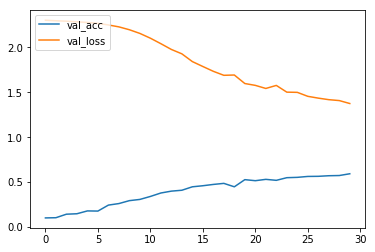

In [66]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_acc'])
plt.plot(history.history['val_loss'])
plt.legend(['val_acc', 'val_loss'], loc='upper left')

plt.show()


In [0]:
y_pred = model.predict(X_test)

In [71]:
print(classification_report(y_test, np.argmax(y_pred, axis=1)))

              precision    recall  f1-score   support

           0       0.56      0.65      0.60      1814
           1       0.61      0.62      0.61      1828
           2       0.54      0.60      0.57      1803
           3       0.54      0.56      0.55      1719
           4       0.60      0.68      0.64      1812
           5       0.56      0.52      0.54      1768
           6       0.61      0.58      0.59      1832
           7       0.69      0.59      0.64      1808
           8       0.61      0.58      0.60      1812
           9       0.64      0.55      0.59      1804

    accuracy                           0.59     18000
   macro avg       0.60      0.59      0.59     18000
weighted avg       0.60      0.59      0.59     18000



### Observation:
Deep Neural Network is able to predict entire y_test dataset in a very short time compared to kNN model and with a greate accuracy of 70%

### With BatchNorm
Lets add a Batch Norm and see how the model performs

In [0]:
model2 = keras.models.Sequential()
model2.add(keras.layers.Dense(200, input_shape=(32,32,), activation='relu'))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Dense(100, activation='relu'))
model2.add(keras.layers.Flatten())
model2.add(keras.layers.Dense(10, activation='softmax'))
model2.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])


In [77]:
history = model2.fit(X_train, y_train_cat,
                    validation_data=(X_test, y_test_cat),
                    batch_size=128,
                    epochs=30)

Train on 42000 samples, validate on 18000 samples
Epoch 1/30
42000/42000 [==============================] - 4s 84us/sample - loss: 2.0055 - acc: 0.3172 - val_loss: 2.0065 - val_acc: 0.3876
Epoch 2/30
42000/42000 [==============================] - 3s 77us/sample - loss: 1.4794 - acc: 0.5505 - val_loss: 1.5466 - val_acc: 0.4947
Epoch 3/30
42000/42000 [==============================] - 3s 75us/sample - loss: 1.3033 - acc: 0.6088 - val_loss: 1.2938 - val_acc: 0.6060
Epoch 4/30
42000/42000 [==============================] - 3s 75us/sample - loss: 1.2169 - acc: 0.6332 - val_loss: 1.3418 - val_acc: 0.5836
Epoch 5/30
42000/42000 [==============================] - 3s 76us/sample - loss: 1.1625 - acc: 0.6539 - val_loss: 1.2967 - val_acc: 0.6025
Epoch 6/30
42000/42000 [==============================] - 3s 75us/sample - loss: 1.1240 - acc: 0.6652 - val_loss: 1.1920 - val_acc: 0.6374
Epoch 7/30
42000/42000 [==============================] - 3s 76us/sample - loss: 1.0910 - acc: 0.6749 - val_loss: 1.

In [78]:
y_pred2 = model2.predict(X_test)
print(classification_report(y_test, np.argmax(y_pred2, axis=1)))

              precision    recall  f1-score   support

           0       0.68      0.67      0.68      1814
           1       0.37      0.80      0.51      1828
           2       0.76      0.56      0.64      1803
           3       0.70      0.50      0.58      1719
           4       0.68      0.67      0.67      1812
           5       0.66      0.59      0.63      1768
           6       0.79      0.51      0.62      1832
           7       0.77      0.60      0.68      1808
           8       0.54      0.67      0.60      1812
           9       0.71      0.59      0.65      1804

    accuracy                           0.62     18000
   macro avg       0.67      0.62      0.62     18000
weighted avg       0.67      0.62      0.62     18000



### Observation
Adding a BathNorm after the first dense layer is improving the results.

## With Adam Optimizer

In [0]:
model3 = keras.models.Sequential()
model3.add(keras.layers.Dense(200, input_shape=(32,32,), activation='relu'))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Dense(100, activation='relu'))
model3.add(keras.layers.Flatten())
model3.add(keras.layers.Dense(10, activation='softmax'))
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [80]:
history = model3.fit(X_train, y_train_cat,
                    validation_data=(X_test, y_test_cat),
                    batch_size=128,
                    epochs=30)

Train on 42000 samples, validate on 18000 samples
Epoch 1/30
42000/42000 [==============================] - 4s 92us/sample - loss: 1.4973 - acc: 0.5283 - val_loss: 1.6635 - val_acc: 0.5865
Epoch 2/30
42000/42000 [==============================] - 3s 82us/sample - loss: 1.1405 - acc: 0.6572 - val_loss: 1.1939 - val_acc: 0.6446
Epoch 3/30
42000/42000 [==============================] - 3s 83us/sample - loss: 1.0662 - acc: 0.6810 - val_loss: 1.2203 - val_acc: 0.6277
Epoch 4/30
42000/42000 [==============================] - 4s 83us/sample - loss: 1.0203 - acc: 0.6902 - val_loss: 1.1722 - val_acc: 0.6436
Epoch 5/30
42000/42000 [==============================] - 3s 83us/sample - loss: 0.9888 - acc: 0.7021 - val_loss: 1.2261 - val_acc: 0.6349
Epoch 6/30
42000/42000 [==============================] - 3s 82us/sample - loss: 0.9571 - acc: 0.7101 - val_loss: 1.1270 - val_acc: 0.6613
Epoch 7/30
42000/42000 [==============================] - 3s 82us/sample - loss: 0.9242 - acc: 0.7193 - val_loss: 1.

In [82]:
y_pred3 = model3.predict(X_test)
print(classification_report(y_test, np.argmax(y_pred3, axis=1)))

              precision    recall  f1-score   support

           0       0.72      0.61      0.66      1814
           1       0.67      0.72      0.69      1828
           2       0.68      0.65      0.66      1803
           3       0.56      0.66      0.61      1719
           4       0.72      0.71      0.71      1812
           5       0.69      0.61      0.65      1768
           6       0.66      0.67      0.67      1832
           7       0.75      0.70      0.73      1808
           8       0.68      0.54      0.60      1812
           9       0.55      0.74      0.63      1804

    accuracy                           0.66     18000
   macro avg       0.67      0.66      0.66     18000
weighted avg       0.67      0.66      0.66     18000



### Observation:
Not much improvement with "adam" optimzer as such.